In [1]:
import logging
from itertools import combinations

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# local .py files
from etl_utils import(
    create_adocell_prefix,
    AIDOCELL_CLASSES_LIST,
    MODELS,
) 
from analysis_utils import (
    load_foundation_summaries,
    get_common_identifiers,
    get_aligned_embeddings,
    select_device,
    compute_cosine_distances_torch,
    compute_spearman_correlation_torch,
    cleanup_tensors,
    memory_manager
)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(name)s:%(message)s')
logger = logging.getLogger(__name__)

aido_cell_prefixes = {create_adocell_prefix(x) for x in AIDOCELL_CLASSES_LIST}
model_prefixes = {MODELS.SCPRINT, MODELS.SCGPT} | aido_cell_prefixes

OUTPUT_DIR = "output"


In [2]:
# load each model's weights, gene annotations, and model metadata
models_dict = load_foundation_summaries(model_prefixes, OUTPUT_DIR)

# Get common identifiers across all models
common_identifiers = get_common_identifiers(models_dict)

# pull out and align embeddings across models
aligned_embeddings = get_aligned_embeddings(models_dict, common_identifiers)

INFO:analysis_utils:Loading results for the AIDOCell_aido_cell_10m foundation model
INFO:etl_utils:Loading weights from output/AIDOCell_aido_cell_10m_weights.npz and metadata from output/AIDOCell_aido_cell_10m_metadata.json
INFO:etl_utils:Loading weights from output/AIDOCell_aido_cell_10m_weights.npz
INFO:etl_utils:Loading metadata from output/AIDOCell_aido_cell_10m_metadata.json
INFO:etl_utils:Successfully loaded and validated all results
INFO:analysis_utils:Loading results for the AIDOCell_aido_cell_3m foundation model
INFO:etl_utils:Loading weights from output/AIDOCell_aido_cell_3m_weights.npz and metadata from output/AIDOCell_aido_cell_3m_metadata.json
INFO:etl_utils:Loading weights from output/AIDOCell_aido_cell_3m_weights.npz
INFO:etl_utils:Loading metadata from output/AIDOCell_aido_cell_3m_metadata.json
INFO:etl_utils:Successfully loaded and validated all results
INFO:analysis_utils:Loading results for the AIDOCell_aido_cell_100m foundation model
INFO:etl_utils:Loading weights f

## Compare embeddings

To assess whether the embeddings are organizing genes in a similar way, I directly compared them. Since their embedding dimensions differ I decided to generate a gene-gene distance matrix (using cosine distance) for each embedding and then I compared all pairs of distance matrices using Spearman correlation.

The highest concordance is between scGPT and scPRINT (rho ~ 0.28) while AIDO.Cell's gene embeddings show low concordance with the other models, and between the different AIDO.Cell models (i.e., the 3M, 10M, and 100M cell models). This may just be a feature of AIDO.Cell's architecture since it uses gene-level positional embeddings which may not actual learn gene-gene similarity.

In [3]:
# Check if MPS/GPU is available
device = select_device(mps_valid = True)
logger.info(f"Using device: {device}")

# Import memory management utilities
from analysis_utils import memory_manager

# Convert embeddings to PyTorch tensors and compute distances with memory management
distances = {}
with memory_manager(device):
    for model_name, embedding in aligned_embeddings.items():
        logger.info(f"Computing distances for {model_name}...")
        distances[model_name] = compute_cosine_distances_torch(embedding, device)

# Compare distance matrices pairwise - all unique pairs from model_prefixes
# Use upper triangle only (exclude diagonal and avoid redundancy)
mask = np.triu_indices(len(common_identifiers), k=1)  # k=1 excludes diagonal

comparisons = {}
with memory_manager(device):
    for model1, model2 in combinations(model_prefixes, 2):
        logger.info(f"Comparing {model1} vs {model2}...")
        
        dist1_flat = distances[model1][mask]
        dist2_flat = distances[model2][mask]
        
        # Spearman correlation using PyTorch 
        rho = compute_spearman_correlation_torch(dist1_flat, dist2_flat, device)
        comparisons[f"{model1}_vs_{model2}"] = rho
        logger.info(f"  {model1} vs {model2}: Spearman rho = {rho:.4f}")
        
    # Clean up intermediate arrays
    del dist1_flat, dist2_flat

print(f"\nFound {len(comparisons)} unique pairwise comparisons:")
for comparison, rho in comparisons.items():
    print(f"  {comparison}: {rho:.4f}")

# Clean up the large distances dictionary to free memory
del distances

INFO:__main__:Using device: mps
INFO:__main__:Computing distances for AIDOCell_aido_cell_10m...
INFO:__main__:Computing distances for AIDOCell_aido_cell_3m...
INFO:__main__:Computing distances for AIDOCell_aido_cell_100m...
INFO:__main__:Computing distances for scGPT...
INFO:__main__:Computing distances for scPRINT...
INFO:__main__:Comparing AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_3m...
INFO:__main__:  AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_3m: Spearman rho = 0.0025
INFO:__main__:Comparing AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_100m...
INFO:__main__:  AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_100m: Spearman rho = 0.0005
INFO:__main__:Comparing AIDOCell_aido_cell_10m vs scGPT...
INFO:__main__:  AIDOCell_aido_cell_10m vs scGPT: Spearman rho = 0.0263
INFO:__main__:Comparing AIDOCell_aido_cell_10m vs scPRINT...
INFO:__main__:  AIDOCell_aido_cell_10m vs scPRINT: Spearman rho = 0.0192
INFO:__main__:Comparing AIDOCell_aido_cell_3m vs AIDOCell_aido_cell_100m...
INFO:__main_


Found 10 unique pairwise comparisons:
  AIDOCell_aido_cell_10m_vs_AIDOCell_aido_cell_3m: 0.0025
  AIDOCell_aido_cell_10m_vs_AIDOCell_aido_cell_100m: 0.0005
  AIDOCell_aido_cell_10m_vs_scGPT: 0.0263
  AIDOCell_aido_cell_10m_vs_scPRINT: 0.0192
  AIDOCell_aido_cell_3m_vs_AIDOCell_aido_cell_100m: 0.0006
  AIDOCell_aido_cell_3m_vs_scGPT: 0.0376
  AIDOCell_aido_cell_3m_vs_scPRINT: 0.0253
  AIDOCell_aido_cell_100m_vs_scGPT: 0.0069
  AIDOCell_aido_cell_100m_vs_scPRINT: 0.0047
  scGPT_vs_scPRINT: 0.3727


## Compare attention

Next, I want to compare the gene-gene attention probabilities (the softmax, makes these a probability distribution for each column) to see how pairs of genes are attending to each other.

In [4]:
from analysis_utils import (
    compute_attention_from_weights
)
from etl_utils import (
    RESULTS_DEFS
)

In [5]:
from typing import Union
import torch

In [6]:
def compute_aggregated_attention(
    gene_embedding: np.ndarray,
    foundation_model_summary: dict,
    device: Union[torch.device, str],
    method: str = "average"
) -> torch.Tensor:

    with memory_manager(device):
        layer_attn_probabilities = _get_all_attention_probabilities(
            gene_embedding,
            foundation_model_summary[RESULTS_DEFS.WEIGHTS_DICT][RESULTS_DEFS.ATTENTION_WEIGHTS],
            device
        )

        if method == "average":
            average_attention = _average_attention_probabilities(layer_attn_probabilities)
        else:
            raise ValueError(f"Invalid method: {method}")
        
        # Clean up intermediate results
        del layer_attn_probabilities
        
        return average_attention

def compute_top_n_attention(
    gene_embedding: np.ndarray,
    foundation_model_summary: dict,
    device: Union[torch.device, str],
    n: int = 10000,
) -> pd.DataFrame:

    with memory_manager(device):
        layer_attn_probabilities = _get_all_attention_probabilities(
            gene_embedding,
            foundation_model_summary[RESULTS_DEFS.WEIGHTS_DICT][RESULTS_DEFS.ATTENTION_WEIGHTS],
            device
        )

        # Collect results for all layers
        results = []
        
        for layer_name, layer_data in layer_attn_probabilities.items():
            # Flatten the attention matrix to get top n globally
            flat_attn = layer_data.flatten()
            
            # Get top n values and their flattened indices
            top_values, flat_indices = torch.topk(flat_attn, min(n, flat_attn.numel()))
            
            # Convert flattened indices to row, col indices
            num_cols = layer_data.shape[1]
            from_indices = flat_indices // num_cols
            to_indices = flat_indices % num_cols
            
            # Move to CPU and convert to lists
            layer_results = pd.DataFrame({
                'layer': layer_name,
                'from': from_indices.cpu().numpy(),
                'to': to_indices.cpu().numpy(),
                'attention': top_values.cpu().numpy()
            })
            
            results.append(layer_results)
        
        return pd.concat(results, ignore_index=True)


def _get_all_attention_probabilities(
    embedding: np.ndarray,
    layers: dict[str, np.ndarray],
    device: Union[torch.device, str]
) -> dict:

    """
    Get all attention probabilities using a subset of the gene embedding and layer-level attention weights

    Parameters
    ----------
    embedding: np.ndarray
        A subset of the gene embedding
    layers: dict[str, np.ndarray]
        A dictionary of layer-level attention weights
    device: Union[torch.device, str]
        The device to run the computation on

    Returns
    -------
    layer_attn_probabilities: dict[str, np.ndarray]
        A dictionary of layer-level attention probabilities
    """
    
    layer_attn_probabilities = {}
    for layer_name, layer_data in layers.items():

        # Compute attention on demand
        layer_attn_probabilities[layer_name] = compute_attention_from_weights(
            embedding,
            layer_data[RESULTS_DEFS.W_Q],
            layer_data[RESULTS_DEFS.W_K],
            device
        )

    return layer_attn_probabilities


def _average_attention_probabilities(layer_attn_probabilities: dict) -> torch.Tensor:

    all_layers = list(layer_attn_probabilities.values())
    return torch.stack(all_layers).mean(dim=0)


### Looking at top attention pairs from each layer and model

1. define attention probabilities for each layer (I x I). Where is I is the length and ordering of `common_identifiers`
2. select the N greatest attention probabilities from each layer returning the row and column indices and the attention probability
3. aggregate across all layers and models and store results as a pd.DataFrame
4. rename row/column indices as ensembl genes using `common_identifiers`
5. for each model cound distinct row (from) and column (to) pairs
6. pivot so there is 1 row per from-to edge and columns represent counts of each pair in the top attentions of each model




In [7]:
N_TOP = 10000
identifier_map = {i: gene_id for i, gene_id in enumerate(common_identifiers)}

top_n_attention = {}
for model_name in model_prefixes:

    top_attentention = compute_top_n_attention(aligned_embeddings[model_name], models_dict[model_name], device, N_TOP)

    # update by positionally indexing the ordered vocab in common_identifiers
    top_attentention['from'] = top_attentention['from'].map(identifier_map)
    top_attentention['to'] = top_attentention['to'].map(identifier_map)

    top_n_attention[model_name] = top_attentention


In [14]:
edges_dict = {k : v.value_counts(["from", "to"]) for k, v in top_n_attention.items()}

# Convert dict to long format, then pivot
dfs = []
for model_name, series in edges_dict.items():
    df = series.reset_index()  # Converts multi-index to columns 'from', 'to', 'count'
    df['model'] = model_name
    dfs.append(df)

# Concatenate all models
long_df = pd.concat(dfs, ignore_index=True)

# Pivot: (from, to) pairs as rows, models as columns
wide_df = (
    long_df
    .pivot(index=['from', 'to'], columns='model', values='count')
    .fillna(0)
    .astype(int)
    .assign(num_models = lambda x: (x > 0).sum(axis=1))
)

display(wide_df.head(5))

model_cols = [col for col in wide_df.columns if col not in ['from', 'to', 'num_models']]

# Create binary presence/absence matrix (1 if edge exists, 0 otherwise)
binary_matrix = (wide_df[model_cols] > 0).astype(int)

# Compute co-occurrence: dot product gives shared edge counts
cooccurrence = binary_matrix.T @ binary_matrix
mask = np.tril(np.ones_like(cooccurrence, dtype=bool), k=-1)
cooccurrence[mask] = np.NaN

display(cooccurrence)


model                            AIDOCell_aido_cell_100m  \
from            to                                         
ENSG00000000003 ENSG00000011422                        0   
                ENSG00000011523                        0   
                ENSG00000011677                        0   
                ENSG00000015153                        0   
                ENSG00000019186                        0   

model                            AIDOCell_aido_cell_10m  \
from            to                                        
ENSG00000000003 ENSG00000011422                       0   
                ENSG00000011523                       0   
                ENSG00000011677                       0   
                ENSG00000015153                       0   
                ENSG00000019186                       0   

model                            AIDOCell_aido_cell_3m  scGPT  scPRINT  \
from            to                                                       
ENSG00000000003 ENSG00000011422                      1      0        0   
                ENSG00000011523                      1      0        0   
                ENSG00000011677                      1      0        0   
                ENSG00000015153                      1      0        0   
                ENSG00000019186                      1      0        0   

model                            num_models  
from            to                           
ENSG00000000003 ENSG00000011422           1  
                ENSG00000011523           1  
                ENSG00000011677           1  
                ENSG00000015153           1  
                ENSG00000019186           1

model,AIDOCell_aido_cell_100m,AIDOCell_aido_cell_10m,AIDOCell_aido_cell_3m,scGPT,scPRINT
model,,,,,
AIDOCell_aido_cell_100m,152615.0,761.0,650.0,56.0,423
AIDOCell_aido_cell_10m,NaN,75602.0,315.0,32.0,217
AIDOCell_aido_cell_3m,NaN,NaN,56380.0,28.0,179
scGPT,NaN,NaN,NaN,9997.0,24
scPRINT,NaN,NaN,NaN,NaN,59055


### Compare attention probability matrices

1. `compute_aggregated_attention` calculates attention probability for each layer and then averages the attention probabilities across all layers.
2. each model's average attention probability matrices (torch.Tensor) are compared. Since attention is assymetric only the diagonal entries are dropped. 

In [ ]:
# Simple average across all layers
aggregated_attention = {}
for model_name in model_prefixes:
    aggregated_attention[model_name] = compute_aggregated_attention(aligned_embeddings[model_name], models_dict[model_name], device)

# Create mask for all off-diagonal entries
n = len(common_identifiers)
mask = ~torch.eye(n, dtype=bool, device=device)

# Compare aggregates using all off-diagonal entries with memory management
with memory_manager(device):
    for model1, model2 in combinations(model_prefixes, 2):
        logger.info(f"Comparing attention {model1} vs {model2}...")
        
        attn1_flat = aggregated_attention[model1][mask]
        attn2_flat = aggregated_attention[model2][mask]
        rho = compute_spearman_correlation_torch(attn1_flat, attn2_flat, device)
        logger.info(f"{model1} vs {model2}: {rho:.4f}")
        
        # Clean up intermediate arrays
        cleanup_tensors(attn1_flat, attn2_flat)


INFO:__main__:Comparing attention AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_3m...
INFO:__main__:Comparing attention AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_100m...


AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_3m: 0.0091


INFO:__main__:Comparing attention AIDOCell_aido_cell_10m vs scGPT...


AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_100m: 0.0003


INFO:__main__:Comparing attention AIDOCell_aido_cell_10m vs scPRINT...


...

AIDOCell_aido_cell_3m vs scPRINT: 0.0046


INFO:__main__:Comparing attention AIDOCell_aido_cell_100m vs scPRINT...


AIDOCell_aido_cell_100m vs scGPT: 0.0001


INFO:__main__:Comparing attention scGPT vs scPRINT...


AIDOCell_aido_cell_100m vs scPRINT: 0.0002
scGPT vs scPRINT: 0.0046


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create a scatterplot for attention comparison
def plot_attention_scatter(attn1_flat, attn2_flat, model1_name, model2_name, 
                          max_points=10000, alpha=0.5, figsize=(10, 8)):
    """
    Create a scatterplot comparing two attention tensors.
    
    Parameters
    ----------
    attn1_flat, attn2_flat : torch.Tensor or np.ndarray
        The flattened attention tensors to compare
    model1_name, model2_name : str
        Names of the models for labeling
    max_points : int
        Maximum number of points to plot (for performance)
    alpha : float
        Transparency of points
    figsize : tuple
        Figure size
    """
    
    # Convert to numpy if needed
    if hasattr(attn1_flat, 'cpu'):
        attn1_flat = attn1_flat.cpu().numpy()
    if hasattr(attn2_flat, 'cpu'):
        attn2_flat = attn2_flat.cpu().numpy()
    
    # Apply log10 transformation (add small epsilon to avoid log(0))
    epsilon = 1e-10
    attn1_log = np.log10(attn1_flat + epsilon)
    attn2_log = np.log10(attn2_flat + epsilon)
    
    # Subsample if too many points
    if len(attn1_log) > max_points:
        indices = np.random.choice(len(attn1_log), max_points, replace=False)
        attn1_subset = attn1_log[indices]
        attn2_subset = attn2_log[indices]
    else:
        attn1_subset = attn1_log
        attn2_subset = attn2_log
    
    # Create the plot
    plt.figure(figsize=figsize)
    plt.scatter(attn1_subset, attn2_subset, alpha=alpha, s=1)
    
    # Add labels and title
    plt.xlabel(f'{model1_name} Attention (log10)')
    plt.ylabel(f'{model2_name} Attention (log10)')
    plt.title(f'Attention Comparison: {model1_name} vs {model2_name} (Log10 Scale)')
    
    # Add correlation info
    from scipy.stats import spearmanr
    rho, p_value = spearmanr(attn1_flat, attn2_flat)
    plt.text(0.05, 0.95, f'Spearman ρ = {rho:.4f}\np-value = {p_value:.2e}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Set axis limits based on data range (not equal aspect ratio)
    x_min, x_max = attn1_subset.min(), attn1_subset.max()
    y_min, y_max = attn2_subset.min(), attn2_subset.max()
    
    # Add some padding to the limits
    x_padding = (x_max - x_min) * 0.05
    y_padding = (y_max - y_min) * 0.05
    
    plt.xlim(x_min - x_padding, x_max + x_padding)
    plt.ylim(y_min - y_padding, y_max + y_padding)
    
    # Add diagonal line for reference (using the log-transformed data range)
    min_val = min(attn1_log.min(), attn2_log.min())
    max_val = max(attn1_log.max(), attn2_log.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Perfect correlation')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"Statistics for {model1_name} vs {model2_name}:")
    print(f"  Number of points: {len(attn1_flat):,}")
    print(f"  Spearman correlation: {rho:.4f}")
    print(f"  P-value: {p_value:.2e}")
    print(f"  {model1_name} range: [{attn1_flat.min():.4f}, {attn1_flat.max():.4f}]")
    print(f"  {model2_name} range: [{attn2_flat.min():.4f}, {attn2_flat.max():.4f}]")
    print(f"  {model1_name} mean: {attn1_flat.mean():.4f}")
    print(f"  {model2_name} mean: {attn2_flat.mean():.4f}")
    print(f"  {model1_name} log10 range: [{attn1_log.min():.4f}, {attn1_log.max():.4f}]")
    print(f"  {model2_name} log10 range: [{attn2_log.min():.4f}, {attn2_log.max():.4f}]")


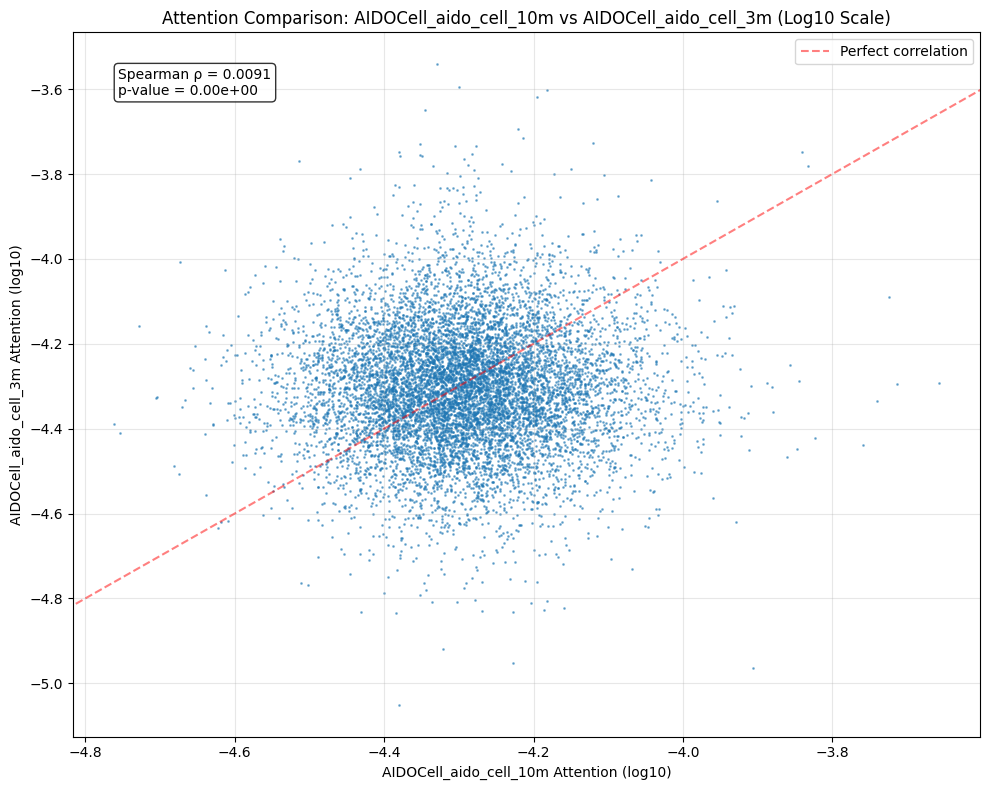

Statistics for AIDOCell_aido_cell_10m vs AIDOCell_aido_cell_3m:
  Number of points: 361,057,002
  Spearman correlation: 0.0091
  P-value: 0.00e+00
  AIDOCell_aido_cell_10m range: [0.0000, 0.0014]
  AIDOCell_aido_cell_3m range: [0.0000, 0.0049]
  AIDOCell_aido_cell_10m mean: 0.0001
  AIDOCell_aido_cell_3m mean: 0.0001
  AIDOCell_aido_cell_10m log10 range: [-5.1699, -2.8585]
  AIDOCell_aido_cell_3m log10 range: [-5.4677, -2.3116]


In [16]:
model1_name = "AIDOCell_aido_cell_3m"
model2_name = "AIDOCell_aido_cell_10m"

# Get the attention data for these models
if model1_name in aggregated_attention and model2_name in aggregated_attention:
    attn1 = aggregated_attention[model1_name]
    attn2 = aggregated_attention[model2_name]
    
    # Create mask for off-diagonal entries (same as in your correlation calculation)
    n = len(common_identifiers)
    mask = ~torch.eye(n, dtype=bool, device=device)
    
    # Flatten the attention matrices
    attn1_flat = attn1[mask]
    attn2_flat = attn2[mask]
    
    # Create the scatterplot
    plot_attention_scatter(attn1_flat, attn2_flat, model1_name, model2_name)
else:
    print(f"Models {model1_name} and/or {model2_name} not found in aggregated_attention")
    print(f"Available models: {list(aggregated_attention.keys())}")
